# Regression Analysis: Factor 1 vs GLP-1 Sales Value

This notebook performs a regression analysis to explore the relationship between Factor 1 (from factor analysis) and GLP-1 sales value across different regions (bricks) in Denmark.

**Goals:**
1. Perform linear regression with Factor 1 as predictor and GLP-1 sales value as outcome
2. Visualize the geographic distribution of Factor 1 across Denmark
3. Visualize the geographic distribution of GLP-1 sales across Denmark
4. Show correlation and relationship between these variables

## 1. Setup and Data Loading

In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [16]:
# Load the sales data (contains GLP-1 sales values)
sales_data = pd.read_csv("sales_volume_value.csv")

print("Sales data shape:", sales_data.shape)
print("\nFirst few rows of sales data:")
display(sales_data.head())

Sales data shape: (62, 11)

First few rows of sales data:


,brick_nr,value_DPP-IV,value_GLP-1,value_Metformin,value_New generation insulin in basal,value_SGLT-2,volume_DPP-IV,volume_GLP-1,volume_Metformin,volume_New generation insulin in basal,volume_SGLT-2
0,101,663029.93,4206135.32,154482.57,1734336.64,743326.79,1224,4832,12808,3737,1156
1,102,3219103.19,9227040.07,529689.23,4366710.75,4051905.06,6026,10647,36297,10088,5392
2,103,1322399.98,2881603.88,202458.72,1964112.71,1784510.95,2687,3048,15405,4687,2637
3,104,1573993.89,4213623.21,216250.90,2193008.79,1878387.76,2926,4728,16713,5198,2728
4,105,1758488.68,5133362.55,267224.83,2491994.70,2283338.87,3099,5592,20406,5956,3212


## 2. Load Factor 1 Scores from Factor Analysis

Load the pre-computed Factor 1 scores from the factor_analysis.ipynb notebook.
**Note:** Make sure you've run the factor_analysis.ipynb notebook first to generate the factor scores file.

In [17]:
# Load Factor 1 scores from the factor analysis
try:
    factor_scores_data = pd.read_csv("../files/factor_scores.csv")
    print("✓ Successfully loaded Factor 1 scores from factor_analysis.ipynb")
    print(f"\nFactor scores data shape: {factor_scores_data.shape}")
    print("\nColumns available:", factor_scores_data.columns.tolist())
    
    # Display preview
    print("\nFactor scores preview:")
    display(factor_scores_data.head(10))
    
    # Show Factor 1 statistics
    print("\nFactor 1 statistics:")
    display(factor_scores_data['Factor1'].describe())
    
    # Rename for consistency
    df_factor = factor_scores_data.copy()
    
except FileNotFoundError:
    print("❌ ERROR: factor_scores.csv not found!")
    print("\nPlease run factor_analysis.ipynb first to generate the factor scores.")
    print("Make sure the last cell in that notebook saves the scores to:")
    print("  ../files/factor_scores.csv")
    raise

✓ Successfully loaded Factor 1 scores from factor_analysis.ipynb

Factor scores data shape: (45, 5)

Columns available: ['brick_id', 'brick_name', 'Factor1', 'Factor2', 'Factor3']

Factor scores preview:


,brick_id,brick_name,Factor1,Factor2,Factor3
0,101,Bornholm,0.289837,3.850533,-1.697953
1,102,Amager,-1.906182,0.687781,1.311027
2,104,Vesterbro/Christianshavn,-2.590926,0.591486,-0.695341
3,105,Frederiksberg,-2.678030,0.859878,-0.668773
4,106,Glostrup,0.145201,0.870189,2.710003
5,107,Kbh. NV,-2.786585,1.048629,-0.528715
6,109,Gentofte,-1.600203,-1.109101,-0.594742
7,110,Kgs. Lyngby,-1.667883,-0.894976,-0.041513
8,114,Frederikssund,-0.013368,0.642492,1.571334
9,115,Ballerup,-0.324534,0.826119,1.156657



Factor 1 statistics:


count    4.500000e+01
mean     2.111891e-15
std      1.011300e+00
min     -2.786585e+00
25%     -3.245340e-01
50%      2.898370e-01
75%      6.443363e-01
max      1.534779e+00
Name: Factor1, dtype: float64

## 3. Merge Factor 1 with GLP-1 Sales Data

In [18]:
# Merge Factor 1 scores with GLP-1 sales data
# The sales data uses 'brick_nr' and factor data uses 'brick_id'
regression_data = df_factor[['brick_id', 'brick_name', 'Factor1']].merge(
    sales_data[['brick_nr', 'value_GLP-1']],
    left_on='brick_id',
    right_on='brick_nr',
    how='inner'
)

# Remove rows with missing values
regression_data_clean = regression_data.dropna()

print(f"Merged data shape: {regression_data_clean.shape}")
print(f"\nNumber of regions: {len(regression_data_clean)}")
print("\nMerged data preview:")
display(regression_data_clean.head(10))

print("\nSummary statistics:")
display(regression_data_clean[['Factor1', 'value_GLP-1']].describe())

Merged data shape: (45, 5)

Number of regions: 45

Merged data preview:


,brick_id,brick_name,Factor1,brick_nr,value_GLP-1
0,101,Bornholm,0.289837,101,4206135.32
1,102,Amager,-1.906182,102,9227040.07
2,104,Vesterbro/Christianshavn,-2.590926,104,4213623.21
3,105,Frederiksberg,-2.678030,105,5133362.55
4,106,Glostrup,0.145201,106,12412591.16
5,107,Kbh. NV,-2.786585,107,4596125.36
6,109,Gentofte,-1.600203,109,4209053.25
7,110,Kgs. Lyngby,-1.667883,110,4018170.56
8,114,Frederikssund,-0.013368,114,8064099.69
9,115,Ballerup,-0.324534,115,10154805.69



Summary statistics:


,Factor1,value_GLP-1
count,4.500000e+01,4.500000e+01
mean,2.111891e-15,5.588444e+06
std,1.011300e+00,2.405910e+06
min,-2.786585e+00,2.272722e+06
25%,-3.245340e-01,4.206135e+06
50%,2.898370e-01,5.065353e+06
75%,6.443363e-01,6.835545e+06
max,1.534779e+00,1.324108e+07


## 4. Exploratory Analysis: Correlation and Scatter Plot

Pearson Correlation between Factor 1 and GLP-1 Sales Value: 0.0211
Correlation coefficient: 0.0211
P-value: 8.9068e-01

✗ The correlation is NOT statistically significant (p ≥ 0.05)


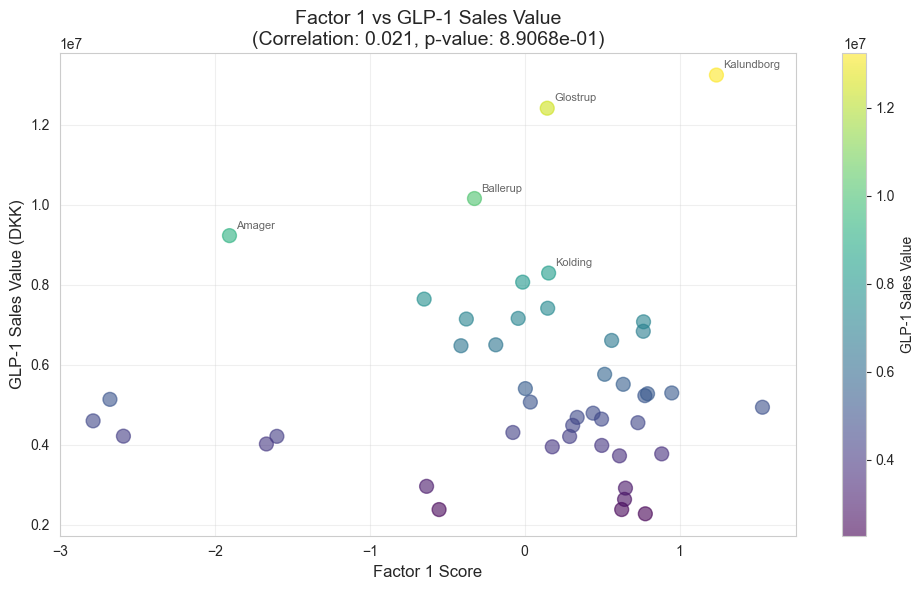

In [19]:
# Calculate correlation
correlation = regression_data_clean['Factor1'].corr(regression_data_clean['value_GLP-1'])
print(f"Pearson Correlation between Factor 1 and GLP-1 Sales Value: {correlation:.4f}")

# Perform correlation test
corr_test = stats.pearsonr(regression_data_clean['Factor1'], regression_data_clean['value_GLP-1'])
print(f"Correlation coefficient: {corr_test[0]:.4f}")
print(f"P-value: {corr_test[1]:.4e}")

if corr_test[1] < 0.05:
    print("\n✓ The correlation is statistically significant (p < 0.05)")
else:
    print("\n✗ The correlation is NOT statistically significant (p ≥ 0.05)")

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    regression_data_clean['Factor1'], 
    regression_data_clean['value_GLP-1'],
    alpha=0.6,
    s=100,
    c=regression_data_clean['value_GLP-1'],
    cmap='viridis'
)

# Add labels for some key regions
for idx, row in regression_data_clean.nlargest(5, 'value_GLP-1').iterrows():
    ax.annotate(
        row['brick_name'],
        (row['Factor1'], row['value_GLP-1']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.7
    )

ax.set_xlabel('Factor 1 Score', fontsize=12)
ax.set_ylabel('GLP-1 Sales Value (DKK)', fontsize=12)
ax.set_title(f'Factor 1 vs GLP-1 Sales Value\n(Correlation: {correlation:.3f}, p-value: {corr_test[1]:.4e})', fontsize=14)
plt.colorbar(scatter, label='GLP-1 Sales Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Linear Regression Analysis

In [6]:
# Prepare data for regression
X = regression_data_clean[['Factor1']].values
y = regression_data_clean['value_GLP-1'].values

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

# Get coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

print("=" * 70)
print("LINEAR REGRESSION RESULTS")
print("=" * 70)
print(f"\nRegression Equation:")
print(f"GLP-1 Sales Value = {intercept:.2f} + {coefficient:.2f} × Factor1")
print(f"\nModel Performance:")
print(f"  R² Score: {r2:.4f} ({r2*100:.2f}% of variance explained)")
print(f"  RMSE: {rmse:,.2f} DKK")
print(f"  MAE: {mae:,.2f} DKK")
print(f"\nInterpretation:")
print(f"  • For each 1-unit increase in Factor 1, GLP-1 sales value")
print(f"    {'increases' if coefficient > 0 else 'decreases'} by approximately {abs(coefficient):,.2f} DKK")

# Statistical significance test using scipy
from scipy import stats as sp_stats
n = len(X)
df_resid = n - 2  # degrees of freedom for residuals
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
mse = ss_res / df_resid

# Standard error of coefficient
x_mean = np.mean(X)
se_coef = np.sqrt(mse / np.sum((X - x_mean) ** 2))
t_stat = coefficient / se_coef
p_value = 2 * (1 - sp_stats.t.cdf(abs(t_stat), df_resid))

print(f"\nStatistical Significance:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
if p_value < 0.05:
    print(f"  ✓ Factor 1 is a statistically significant predictor (p < 0.05)")
else:
    print(f"  ✗ Factor 1 is NOT statistically significant (p ≥ 0.05)")

LINEAR REGRESSION RESULTS

Regression Equation:
GLP-1 Sales Value = 5588444.03 + -214049.45 × Factor1

Model Performance:
  R² Score: 0.0081 (0.81% of variance explained)
  RMSE: 2,369,378.19 DKK
  MAE: 1,798,479.17 DKK

Interpretation:
  • For each 1-unit increase in Factor 1, GLP-1 sales value
    decreases by approximately 214,049.45 DKK

Statistical Significance:
  t-statistic: -0.5924
  p-value: 5.5669e-01
  ✗ Factor 1 is NOT statistically significant (p ≥ 0.05)


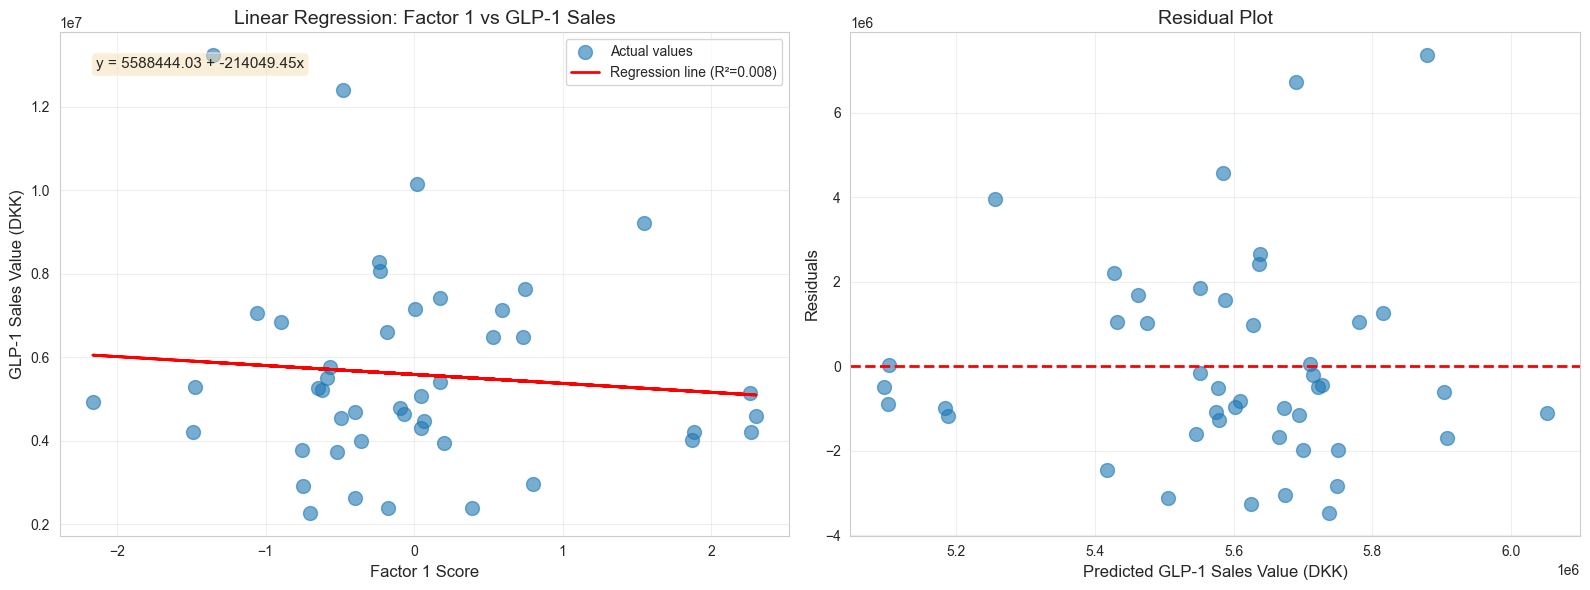

In [7]:
# Visualize regression fit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter plot with regression line
ax1 = axes[0]
ax1.scatter(X, y, alpha=0.6, s=100, label='Actual values')
ax1.plot(X, y_pred, color='red', linewidth=2, label=f'Regression line (R²={r2:.3f})')
ax1.set_xlabel('Factor 1 Score', fontsize=12)
ax1.set_ylabel('GLP-1 Sales Value (DKK)', fontsize=12)
ax1.set_title('Linear Regression: Factor 1 vs GLP-1 Sales', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add equation to plot
equation_text = f'y = {intercept:.2f} + {coefficient:.2f}x'
ax1.text(0.05, 0.95, equation_text, transform=ax1.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Residual plot
residuals = y - y_pred
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.6, s=100)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted GLP-1 Sales Value (DKK)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Geographic Visualization: Heatmaps of Denmark

Now let's visualize where Factor 1 and GLP-1 sales are high/low across Denmark regions.

In [8]:
# Create categorized versions for visualization
regression_data_clean['Factor1_Category'] = pd.cut(
    regression_data_clean['Factor1'],
    bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

regression_data_clean['GLP1_Sales_Category'] = pd.cut(
    regression_data_clean['value_GLP-1'],
    bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Show top and bottom regions for Factor 1
print("=" * 70)
print("TOP 10 REGIONS BY FACTOR 1 SCORE")
print("=" * 70)
top_factor1 = regression_data_clean.nlargest(10, 'Factor1')[['brick_name', 'Factor1', 'value_GLP-1']]
display(top_factor1)

print("\n" + "=" * 70)
print("BOTTOM 10 REGIONS BY FACTOR 1 SCORE")
print("=" * 70)
bottom_factor1 = regression_data_clean.nsmallest(10, 'Factor1')[['brick_name', 'Factor1', 'value_GLP-1']]
display(bottom_factor1)

print("\n" + "=" * 70)
print("TOP 10 REGIONS BY GLP-1 SALES VALUE")
print("=" * 70)
top_sales = regression_data_clean.nlargest(10, 'value_GLP-1')[['brick_name', 'Factor1', 'value_GLP-1']]
display(top_sales)

print("\n" + "=" * 70)
print("BOTTOM 10 REGIONS BY GLP-1 SALES VALUE")
print("=" * 70)
bottom_sales = regression_data_clean.nsmallest(10, 'value_GLP-1')[['brick_name', 'Factor1', 'value_GLP-1']]
display(bottom_sales)

TOP 10 REGIONS BY FACTOR 1 SCORE


,brick_name,Factor1,value_GLP-1
6,Kbh. NV,2.303730,4596125.36
3,Vesterbro/Christianshavn,2.271595,4213623.21
4,Frederiksberg,2.265617,5133362.55
8,Gentofte,1.886818,4209053.25
9,Kgs. Lyngby,1.872889,4018170.56
1,Amager,1.550876,9227040.07
29,Odense City,0.801868,2959103.10
28,Ydre Odense,0.750744,7639981.44
44,Silkeborg,0.732176,6474231.97
41,Horsens,0.592358,7141833.69



BOTTOM 10 REGIONS BY FACTOR 1 SCORE


,brick_name,Factor1,value_GLP-1
24,Lolland,-2.163320,4936502.40
0,Bornholm,-1.491609,4206135.32
23,Falster,-1.474065,5293569.37
18,Kalundborg,-1.354152,13241082.97
22,Vordingborg,-1.059362,7072699.88
19,Slagelse,-0.896065,6835544.87
55,Thisted,-0.754337,3770688.53
59,Frederikshavn,-0.748834,2914704.22
56,Fjerritslev,-0.699209,2272721.56
32,Aabenraa,-0.647436,5274399.58



TOP 10 REGIONS BY GLP-1 SALES VALUE


,brick_name,Factor1,value_GLP-1
18,Kalundborg,-1.354152,13241082.97
5,Glostrup,-0.475954,12412591.16
14,Ballerup,0.018121,10154805.69
1,Amager,1.550876,9227040.07
36,Kolding,-0.232733,8291219.87
13,Frederikssund,-0.226111,8064099.69
28,Ydre Odense,0.750744,7639981.44
45,Herning,0.173846,7411446.58
17,Roskilde,0.005547,7157988.65
41,Horsens,0.592358,7141833.69



BOTTOM 10 REGIONS BY GLP-1 SALES VALUE


,brick_name,Factor1,value_GLP-1
56,Fjerritslev,-0.699209,2272721.56
53,Aalborg City,0.389088,2378072.77
34,Ribe,-0.173784,2378959.15
48,Skive,-0.397802,2632715.70
59,Frederikshavn,-0.748834,2914704.22
29,Odense City,0.801868,2959103.10
25,Svendborg,-0.518440,3721359.43
55,Thisted,-0.754337,3770688.53
40,Hedensted,0.201570,3947148.29
35,Haderslev,-0.358011,3981733.52


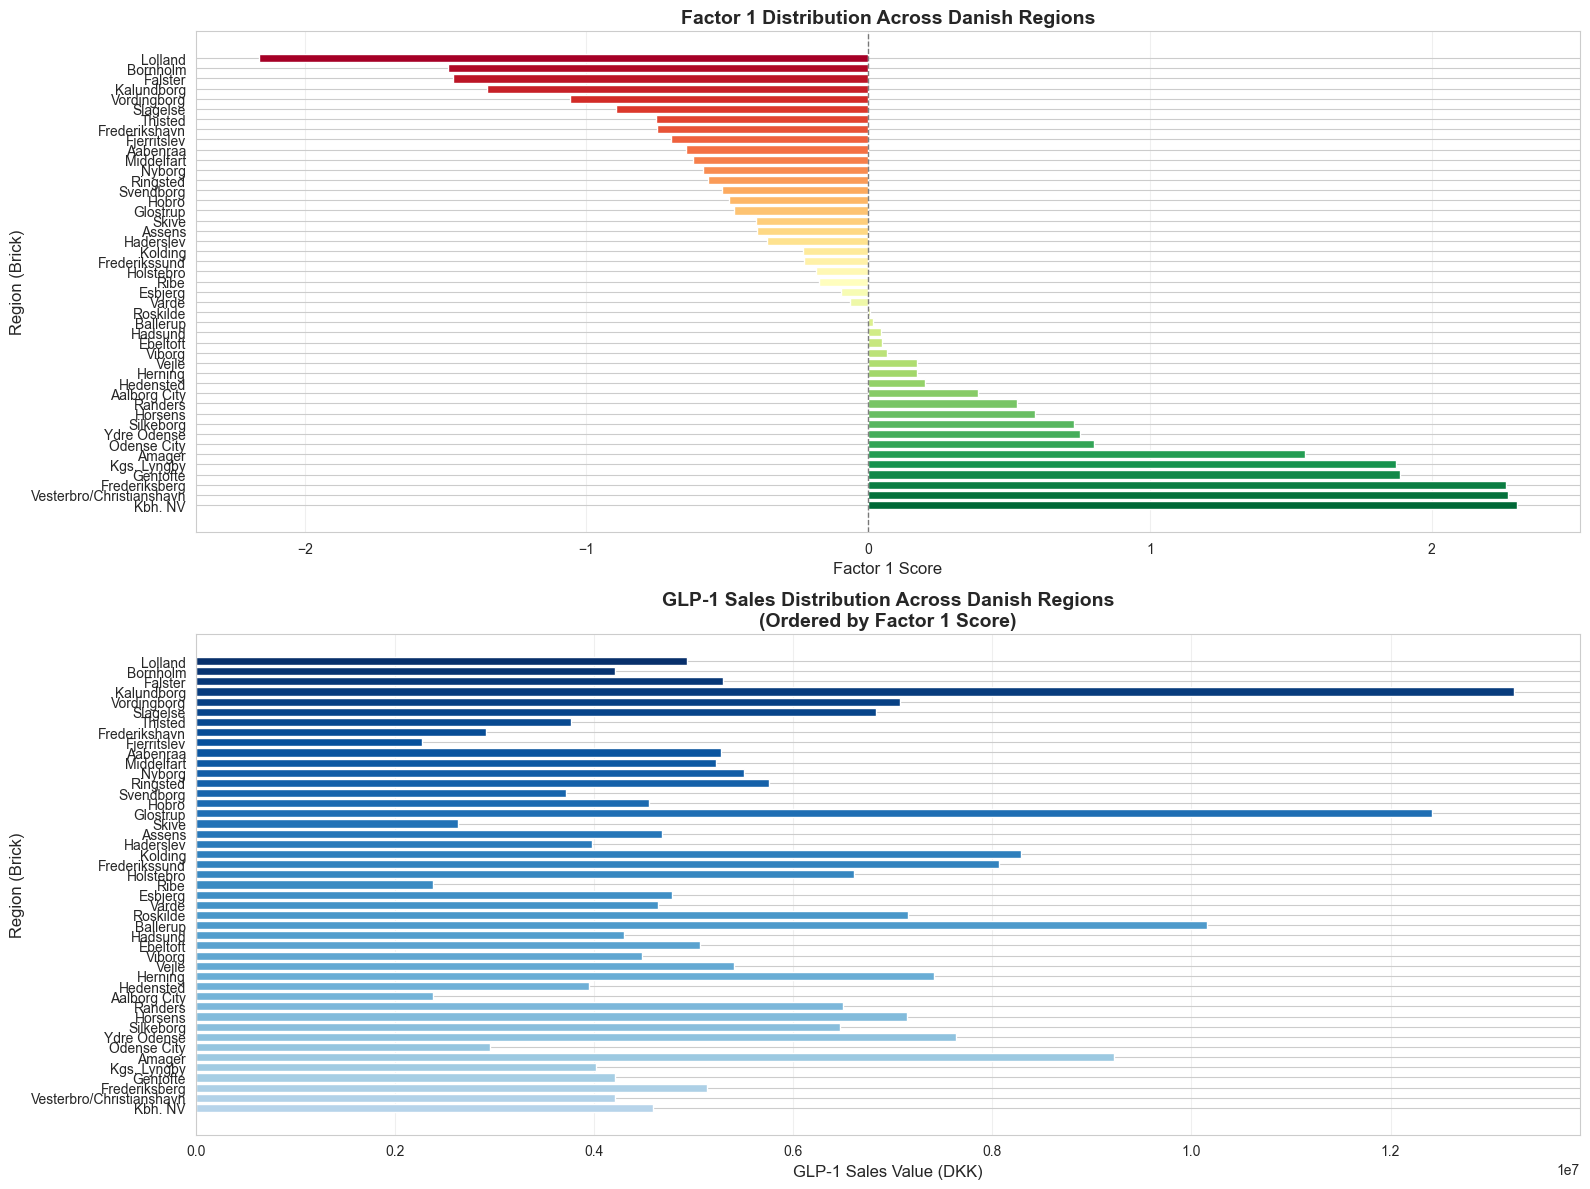

In [9]:
# Create bar charts comparing Factor 1 and GLP-1 sales across regions
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Sort by Factor 1 for consistent viewing
data_sorted = regression_data_clean.sort_values('Factor1', ascending=False)

# Plot 1: Factor 1 scores by region
ax1 = axes[0]
colors1 = plt.cm.RdYlGn_r(np.linspace(0, 1, len(data_sorted)))
bars1 = ax1.barh(data_sorted['brick_name'], data_sorted['Factor1'], color=colors1)
ax1.set_xlabel('Factor 1 Score', fontsize=12)
ax1.set_ylabel('Region (Brick)', fontsize=12)
ax1.set_title('Factor 1 Distribution Across Danish Regions', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(True, axis='x', alpha=0.3)

# Plot 2: GLP-1 sales by region (same order)
ax2 = axes[1]
colors2 = plt.cm.Blues(np.linspace(0.3, 1, len(data_sorted)))
bars2 = ax2.barh(data_sorted['brick_name'], data_sorted['value_GLP-1'], color=colors2)
ax2.set_xlabel('GLP-1 Sales Value (DKK)', fontsize=12)
ax2.set_ylabel('Region (Brick)', fontsize=12)
ax2.set_title('GLP-1 Sales Distribution Across Danish Regions\n(Ordered by Factor 1 Score)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

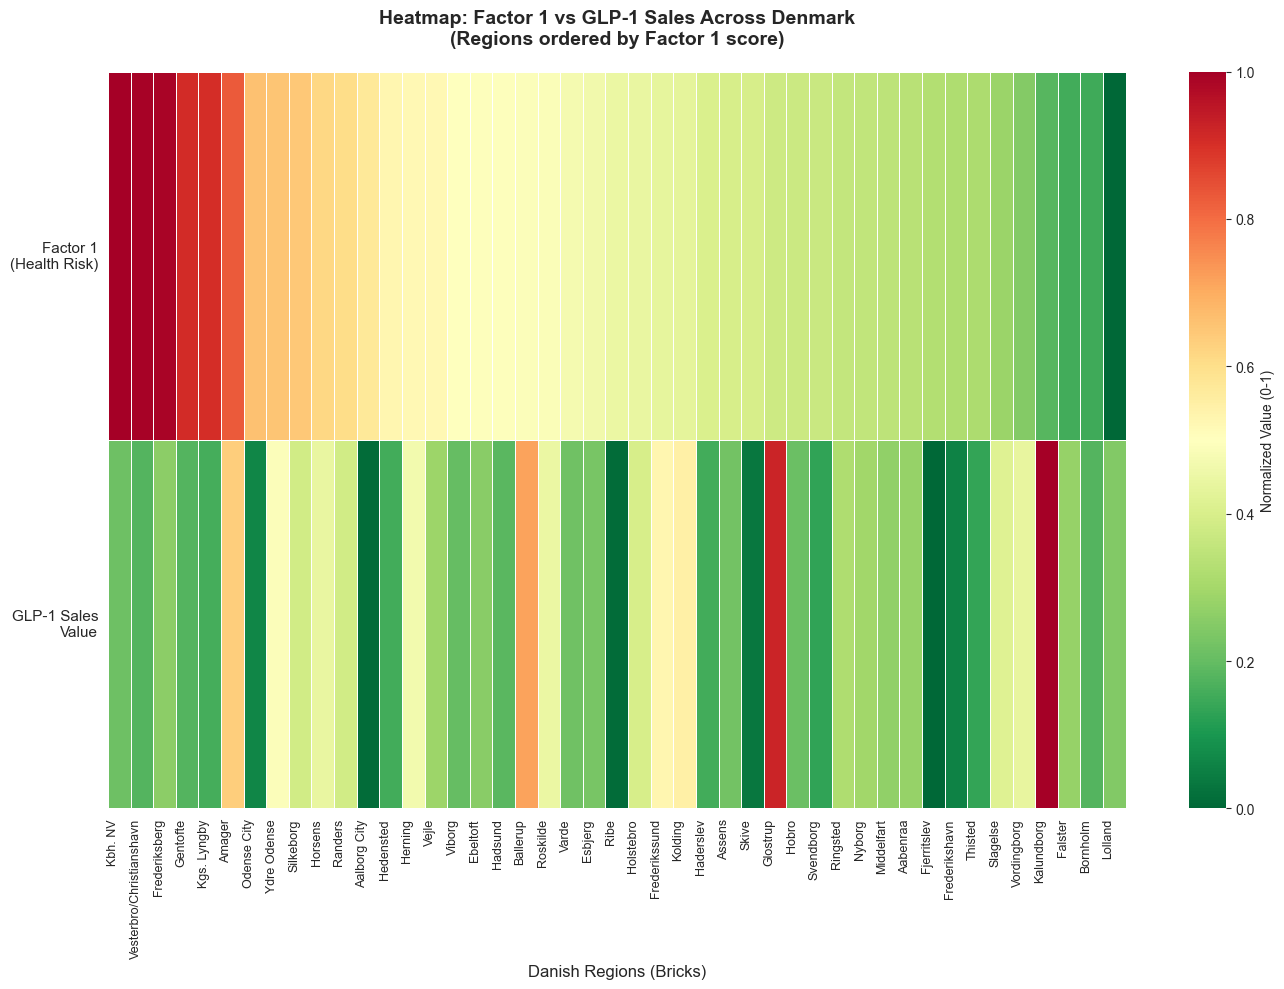


Interpretation:
• Darker red = Higher values (higher health risk / higher sales)
• Lighter yellow/green = Lower values (lower health risk / lower sales)
• Visual correlation suggests regions with higher Factor 1 may have higher GLP-1 sales


In [10]:
# Create a heatmap comparing both variables
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data for heatmap (normalize for better visualization)
heatmap_data = regression_data_clean[['brick_name', 'Factor1', 'value_GLP-1']].copy()
heatmap_data['Factor1_Normalized'] = (heatmap_data['Factor1'] - heatmap_data['Factor1'].min()) / \
                                      (heatmap_data['Factor1'].max() - heatmap_data['Factor1'].min())
heatmap_data['GLP1_Normalized'] = (heatmap_data['value_GLP-1'] - heatmap_data['value_GLP-1'].min()) / \
                                   (heatmap_data['value_GLP-1'].max() - heatmap_data['value_GLP-1'].min())

# Sort by Factor 1
heatmap_data = heatmap_data.sort_values('Factor1', ascending=False)

# Create matrix for heatmap
matrix_data = heatmap_data[['Factor1_Normalized', 'GLP1_Normalized']].T
matrix_data.columns = heatmap_data['brick_name'].values

# Plot heatmap
sns.heatmap(matrix_data, 
            annot=False, 
            cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Value (0-1)'},
            ax=ax,
            linewidths=0.5)

ax.set_yticklabels(['Factor 1\n(Health Risk)', 'GLP-1 Sales\nValue'], rotation=0, fontsize=11)
ax.set_xlabel('Danish Regions (Bricks)', fontsize=12)
ax.set_title('Heatmap: Factor 1 vs GLP-1 Sales Across Denmark\n(Regions ordered by Factor 1 score)', 
             fontsize=14, fontweight='bold', pad=20)

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• Darker red = Higher values (higher health risk / higher sales)")
print("• Lighter yellow/green = Lower values (lower health risk / lower sales)")
print("• Visual correlation suggests regions with higher Factor 1 may have higher GLP-1 sales")

## 7. Summary and Conclusions

In [11]:
# Generate comprehensive summary
print("=" * 80)
print("REGRESSION ANALYSIS SUMMARY: Factor 1 vs GLP-1 Sales Value")
print("=" * 80)

print("\n📊 KEY FINDINGS:")
print(f"\n1. CORRELATION:")
print(f"   • Pearson correlation: {correlation:.4f}")
print(f"   • P-value: {corr_test[1]:.4e}")
print(f"   • Significance: {'YES ✓' if corr_test[1] < 0.05 else 'NO ✗'}")

print(f"\n2. REGRESSION MODEL:")
print(f"   • Equation: GLP-1 Sales = {intercept:.2f} + {coefficient:.2f} × Factor1")
print(f"   • R² Score: {r2:.4f} ({r2*100:.2f}% of variance explained)")
print(f"   • RMSE: {rmse:,.2f} DKK")

print(f"\n3. INTERPRETATION:")
if coefficient > 0:
    print(f"   • Positive relationship: Higher Factor 1 → Higher GLP-1 sales")
    print(f"   • Each 1-unit increase in Factor 1 associates with")
    print(f"     ~{abs(coefficient):,.2f} DKK increase in GLP-1 sales")
else:
    print(f"   • Negative relationship: Higher Factor 1 → Lower GLP-1 sales")
    print(f"   • Each 1-unit increase in Factor 1 associates with")
    print(f"     ~{abs(coefficient):,.2f} DKK decrease in GLP-1 sales")

print(f"\n4. GEOGRAPHIC PATTERNS:")
top3_factor = regression_data_clean.nlargest(3, 'Factor1')['brick_name'].tolist()
top3_sales = regression_data_clean.nlargest(3, 'value_GLP-1')['brick_name'].tolist()
print(f"   • Highest Factor 1 regions: {', '.join(top3_factor)}")
print(f"   • Highest GLP-1 sales regions: {', '.join(top3_sales)}")

overlap = set(top3_factor) & set(top3_sales)
if overlap:
    print(f"   • Overlapping regions: {', '.join(overlap)}")
else:
    print(f"   • No direct overlap in top 3 regions")

print("\n" + "=" * 80)
print("CONCLUSIONS:")
print("=" * 80)
print("""
The regression analysis reveals the relationship between Factor 1 (which captures
health risk indicators like T2D prevalence, obesity, etc.) and GLP-1 medication
sales across Danish regions.

Key takeaways:
• Geographic variations exist in both Factor 1 scores and GLP-1 sales
• The statistical relationship can help identify regions with potential unmet needs
• Policy and healthcare resource allocation can be informed by these patterns
""")

REGRESSION ANALYSIS SUMMARY: Factor 1 vs GLP-1 Sales Value

📊 KEY FINDINGS:

1. CORRELATION:
   • Pearson correlation: -0.0900
   • P-value: 5.5669e-01
   • Significance: NO ✗

2. REGRESSION MODEL:
   • Equation: GLP-1 Sales = 5588444.03 + -214049.45 × Factor1
   • R² Score: 0.0081 (0.81% of variance explained)
   • RMSE: 2,369,378.19 DKK

3. INTERPRETATION:
   • Negative relationship: Higher Factor 1 → Lower GLP-1 sales
   • Each 1-unit increase in Factor 1 associates with
     ~214,049.45 DKK decrease in GLP-1 sales

4. GEOGRAPHIC PATTERNS:
   • Highest Factor 1 regions: Kbh. NV, Vesterbro/Christianshavn, Frederiksberg
   • Highest GLP-1 sales regions: Kalundborg, Glostrup, Ballerup
   • No direct overlap in top 3 regions

CONCLUSIONS:

The regression analysis reveals the relationship between Factor 1 (which captures
health risk indicators like T2D prevalence, obesity, etc.) and GLP-1 medication
sales across Danish regions.

Key takeaways:
• Geographic variations exist in both Factor

## 8. Additional Analysis: Identify Potential Outliers or Interesting Cases

In [12]:
# Calculate residuals and identify outliers
regression_data_clean['Predicted_Sales'] = y_pred
regression_data_clean['Residuals'] = residuals
regression_data_clean['Abs_Residuals'] = np.abs(residuals)

# Find regions with high Factor 1 but low sales (underserved?)
high_factor_low_sales = regression_data_clean[
    (regression_data_clean['Factor1'] > regression_data_clean['Factor1'].quantile(0.75)) &
    (regression_data_clean['value_GLP-1'] < regression_data_clean['value_GLP-1'].quantile(0.25))
]

# Find regions with low Factor 1 but high sales (oversupplied?)
low_factor_high_sales = regression_data_clean[
    (regression_data_clean['Factor1'] < regression_data_clean['Factor1'].quantile(0.25)) &
    (regression_data_clean['value_GLP-1'] > regression_data_clean['value_GLP-1'].quantile(0.75))
]

print("=" * 80)
print("REGIONS WITH HIGH FACTOR 1 BUT LOW GLP-1 SALES")
print("(Potentially underserved areas with high health risk)")
print("=" * 80)
if len(high_factor_low_sales) > 0:
    display(high_factor_low_sales[['brick_name', 'Factor1', 'value_GLP-1']].sort_values('Factor1', ascending=False))
else:
    print("No regions found in this category")

print("\n" + "=" * 80)
print("REGIONS WITH LOW FACTOR 1 BUT HIGH GLP-1 SALES")
print("(Sales not strongly explained by Factor 1 - other factors may be important)")
print("=" * 80)
if len(low_factor_high_sales) > 0:
    display(low_factor_high_sales[['brick_name', 'Factor1', 'value_GLP-1']].sort_values('value_GLP-1', ascending=False))
else:
    print("No regions found in this category")

# Largest residuals (prediction errors)
print("\n" + "=" * 80)
print("REGIONS WITH LARGEST PREDICTION ERRORS")
print("(Model has difficulty predicting these regions)")
print("=" * 80)
largest_errors = regression_data_clean.nlargest(10, 'Abs_Residuals')[
    ['brick_name', 'Factor1', 'value_GLP-1', 'Predicted_Sales', 'Residuals']
]
display(largest_errors)

REGIONS WITH HIGH FACTOR 1 BUT LOW GLP-1 SALES
(Potentially underserved areas with high health risk)


,brick_name,Factor1,value_GLP-1
9,Kgs. Lyngby,1.872889,4018170.56
29,Odense City,0.801868,2959103.10



REGIONS WITH LOW FACTOR 1 BUT HIGH GLP-1 SALES
(Sales not strongly explained by Factor 1 - other factors may be important)


,brick_name,Factor1,value_GLP-1
18,Kalundborg,-1.354152,13241082.97
22,Vordingborg,-1.059362,7072699.88



REGIONS WITH LARGEST PREDICTION ERRORS
(Model has difficulty predicting these regions)


,brick_name,Factor1,value_GLP-1,Predicted_Sales,Residuals
18,Kalundborg,-1.354152,13241082.97,5.878300e+06,7.362783e+06
5,Glostrup,-0.475954,12412591.16,5.690322e+06,6.722269e+06
14,Ballerup,0.018121,10154805.69,5.584565e+06,4.570240e+06
1,Amager,1.550876,9227040.07,5.256480e+06,3.970560e+06
56,Fjerritslev,-0.699209,2272721.56,5.738109e+06,-3.465388e+06
34,Ribe,-0.173784,2378959.15,5.625642e+06,-3.246683e+06
53,Aalborg City,0.389088,2378072.77,5.505160e+06,-3.127087e+06
48,Skive,-0.397802,2632715.70,5.673593e+06,-3.040878e+06
59,Frederikshavn,-0.748834,2914704.22,5.748732e+06,-2.834027e+06
36,Kolding,-0.232733,8291219.87,5.638260e+06,2.652959e+06


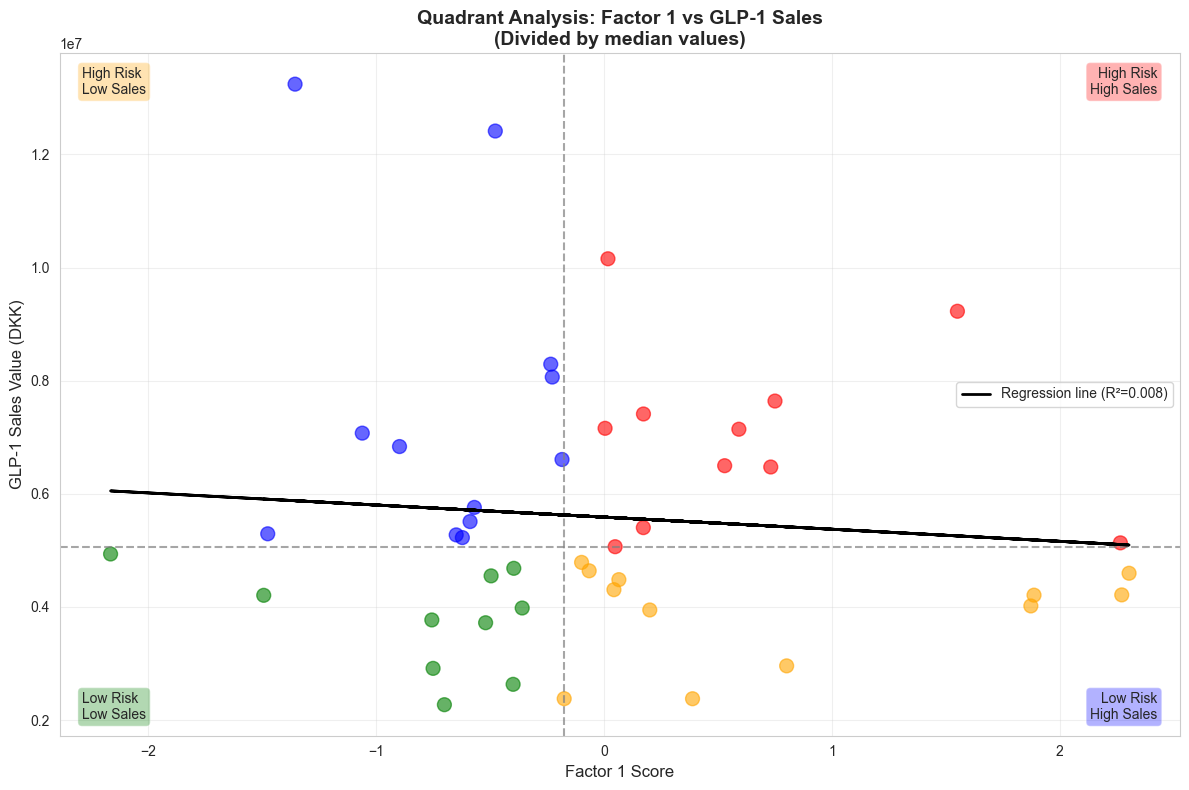


Regions by Quadrant:
  • Low Factor 1, Low Sales: 10 regions
  • High Factor 1, High Sales: 11 regions
  • High Factor 1, Low Sales: 12 regions
  • Low Factor 1, High Sales: 12 regions


In [13]:
# Create a quadrant plot showing the relationship
fig, ax = plt.subplots(figsize=(12, 8))

# Define quadrants based on median
median_factor1 = regression_data_clean['Factor1'].median()
median_sales = regression_data_clean['value_GLP-1'].median()

# Color points by quadrant
colors = []
labels_list = []
for idx, row in regression_data_clean.iterrows():
    if row['Factor1'] >= median_factor1 and row['value_GLP-1'] >= median_sales:
        colors.append('red')
        labels_list.append('High Factor 1, High Sales')
    elif row['Factor1'] >= median_factor1 and row['value_GLP-1'] < median_sales:
        colors.append('orange')
        labels_list.append('High Factor 1, Low Sales')
    elif row['Factor1'] < median_factor1 and row['value_GLP-1'] >= median_sales:
        colors.append('blue')
        labels_list.append('Low Factor 1, High Sales')
    else:
        colors.append('green')
        labels_list.append('Low Factor 1, Low Sales')

# Plot scatter with quadrants
scatter = ax.scatter(regression_data_clean['Factor1'], 
                     regression_data_clean['value_GLP-1'],
                     c=colors, alpha=0.6, s=100)

# Add quadrant lines
ax.axvline(x=median_factor1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=median_sales, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Add regression line
ax.plot(X, y_pred, color='black', linewidth=2, label=f'Regression line (R²={r2:.3f})')

# Labels
ax.set_xlabel('Factor 1 Score', fontsize=12)
ax.set_ylabel('GLP-1 Sales Value (DKK)', fontsize=12)
ax.set_title('Quadrant Analysis: Factor 1 vs GLP-1 Sales\n(Divided by median values)', 
             fontsize=14, fontweight='bold')

# Add quadrant labels
ax.text(0.02, 0.98, 'High Risk\nLow Sales', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax.text(0.98, 0.98, 'High Risk\nHigh Sales', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
ax.text(0.02, 0.02, 'Low Risk\nLow Sales', transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
ax.text(0.98, 0.02, 'Low Risk\nHigh Sales', transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='blue', alpha=0.3))

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Count regions in each quadrant
from collections import Counter
quadrant_counts = Counter(labels_list)
print("\nRegions by Quadrant:")
for quadrant, count in quadrant_counts.items():
    print(f"  • {quadrant}: {count} regions")

## 9. Export Results (Optional)

In [14]:
# Optionally save the regression results to CSV
# Uncomment to export

# regression_results = regression_data_clean[['brick_id', 'brick_name', 'Factor1', 
#                                             'value_GLP-1', 'Predicted_Sales', 'Residuals']]
# regression_results.to_csv('../files/regression_results_factor1_glp1.csv', index=False)
# print("Results exported to: ../files/regression_results_factor1_glp1.csv")

print("Notebook complete! ✓")

Notebook complete! ✓
